# 05 Variance and Historical Contribution

Replicate the main logic of Figures 4 and 5. This version keeps a Stata-compatible historical smoothing series so the output stays parallel with the original replication code, while also writing corrected moving-average columns.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data import get_paths, ensure_output_dirs
paths = get_paths()
ensure_output_dirs(paths)
print('Project root:', PROJECT_ROOT)
print('Original root:', paths.original_root)

Project root: C:\Users\asus\Desktop\Inequality_CGKS_replication_folder\python_replication
Original root: C:\Users\asus\Desktop\Inequality_CGKS_replication_folder\replication_folder


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from src.data import load_cex_short
from src.local_projection import variance_decomposition, historical_contribution
from src.plots import FIG3_VARS, savefig, paper_style, shade_recessions
from src.metrics import write_table

df = load_cex_short(paths)
vd = {}
for var, title, measure in FIG3_VARS:
    frame = variance_decomposition(df, var)
    frame['variable'] = var
    frame['title'] = title
    frame['measure'] = measure
    vd[var] = frame
vd_table = pd.concat(vd.values(), ignore_index=True)
write_table(vd_table, paths.tables / '05_variance_decomposition.csv')
vd_table.head()

,horizon,contribution,variable,title,measure
0,0,0.002443,D_SD_LNYBTIMP2_SA,Income,st.dev.
1,1,0.002571,D_SD_LNYBTIMP2_SA,Income,st.dev.
2,2,0.002818,D_SD_LNYBTIMP2_SA,Income,st.dev.
3,3,0.004401,D_SD_LNYBTIMP2_SA,Income,st.dev.
4,4,0.004891,D_SD_LNYBTIMP2_SA,Income,st.dev.


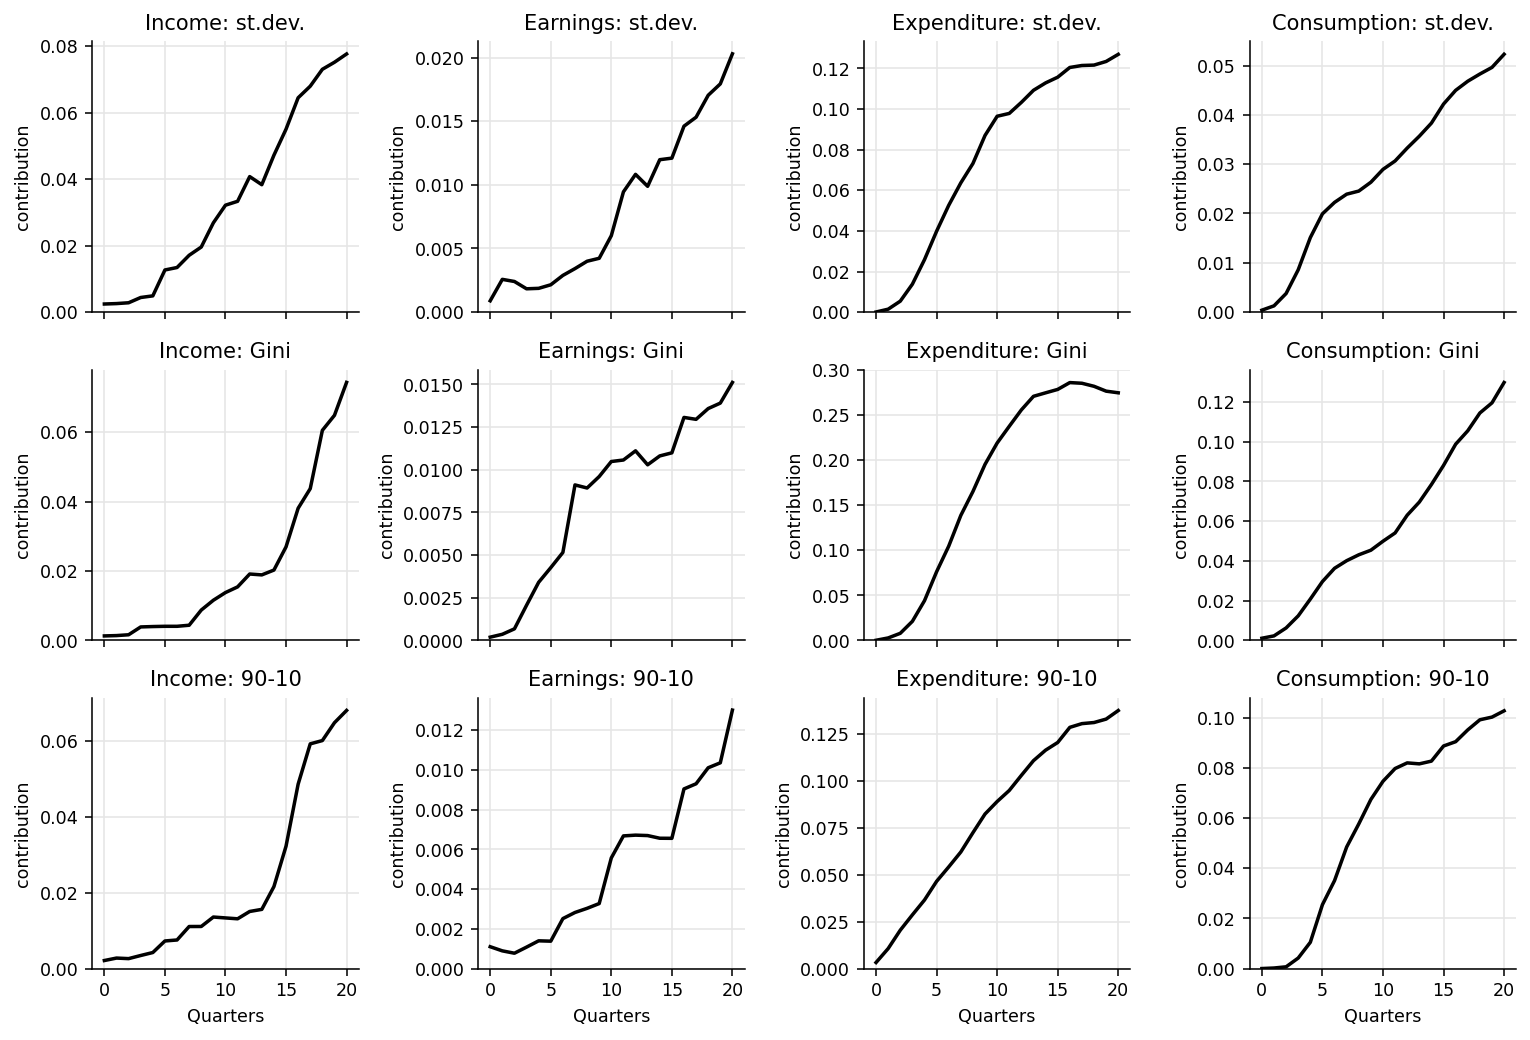

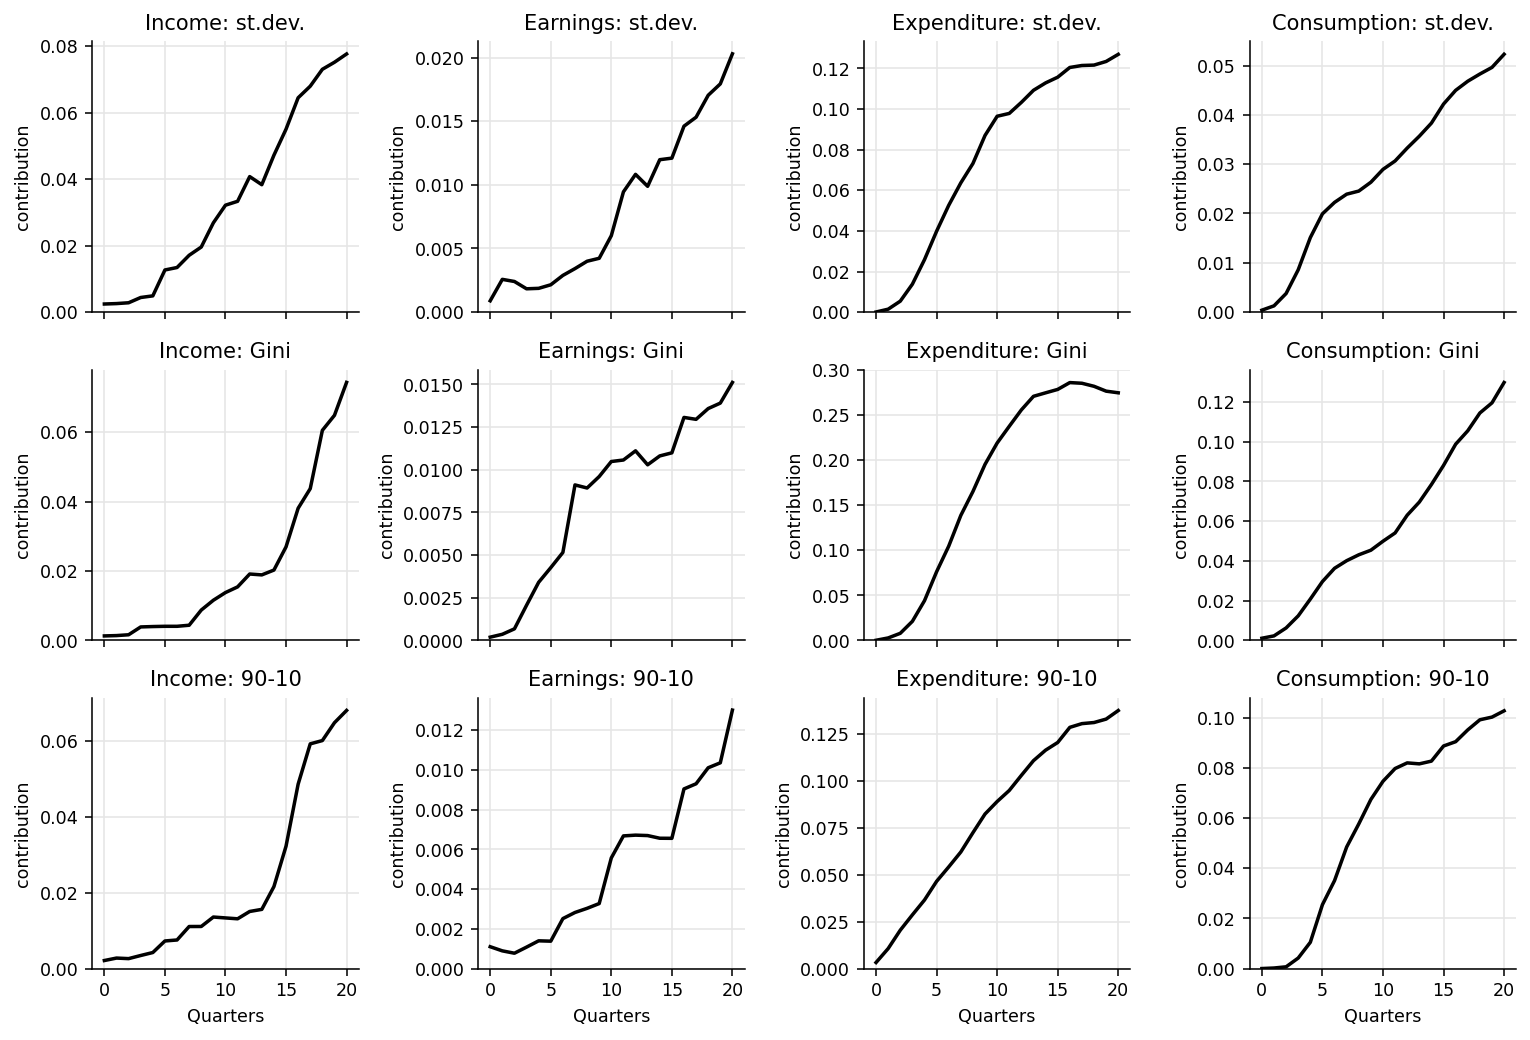

In [3]:
paper_style()
fig, axes = plt.subplots(3, 4, figsize=(11, 7.5), sharex=True)
for ax, (var, title, measure) in zip(axes.ravel(), FIG3_VARS):
    frame = vd[var]
    ax.plot(frame['horizon'], frame['contribution'], color='black', lw=1.8)
    ax.set_title(f'{title}: {measure}')
    ax.set_ylabel('contribution')
    ax.set_ylim(bottom=0)
for ax in axes[-1, :]:
    ax.set_xlabel('Quarters')
savefig(fig, paths.figures / 'figure4_variance_decomposition.png')
fig

In [4]:
hist_vars = [('D_SD_LNYBTIMP2_SA','Income'), ('D_SD_LNSALARYIMP_SA','Earnings'), ('D_SD_LNTOTALEXP3_SA','Expenditure'), ('D_SD_LNCONS_SA','Consumption')]
hist = {var: historical_contribution(df, var, shock_var='sh_rr') for var, _ in hist_vars}
write_table(pd.concat([v.assign(variable=k) for k, v in hist.items()]), paths.tables / '05_historical_contribution.csv')

C:\Users\asus\Desktop\Inequality_CGKS_replication_folder\python_replication\src\local_projection.py:472: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-0.06434358656406482' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  sim_all.loc[t] = sum(fit.params[k] * row[k] for k in fit.params.index)
C:\Users\asus\Desktop\Inequality_CGKS_replication_folder\python_replication\src\local_projection.py:473: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-0.009355566655756216' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  sim_no_shock.loc[t] = sum(fit.params[k] * row0[k] for k in fit.params.index)


C:\Users\asus\Desktop\Inequality_CGKS_replication_folder\python_replication\src\local_projection.py:472: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-0.0031859700102347933' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  sim_all.loc[t] = sum(fit.params[k] * row[k] for k in fit.params.index)
C:\Users\asus\Desktop\Inequality_CGKS_replication_folder\python_replication\src\local_projection.py:473: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-0.00875125484251825' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  sim_no_shock.loc[t] = sum(fit.params[k] * row0[k] for k in fit.params.index)


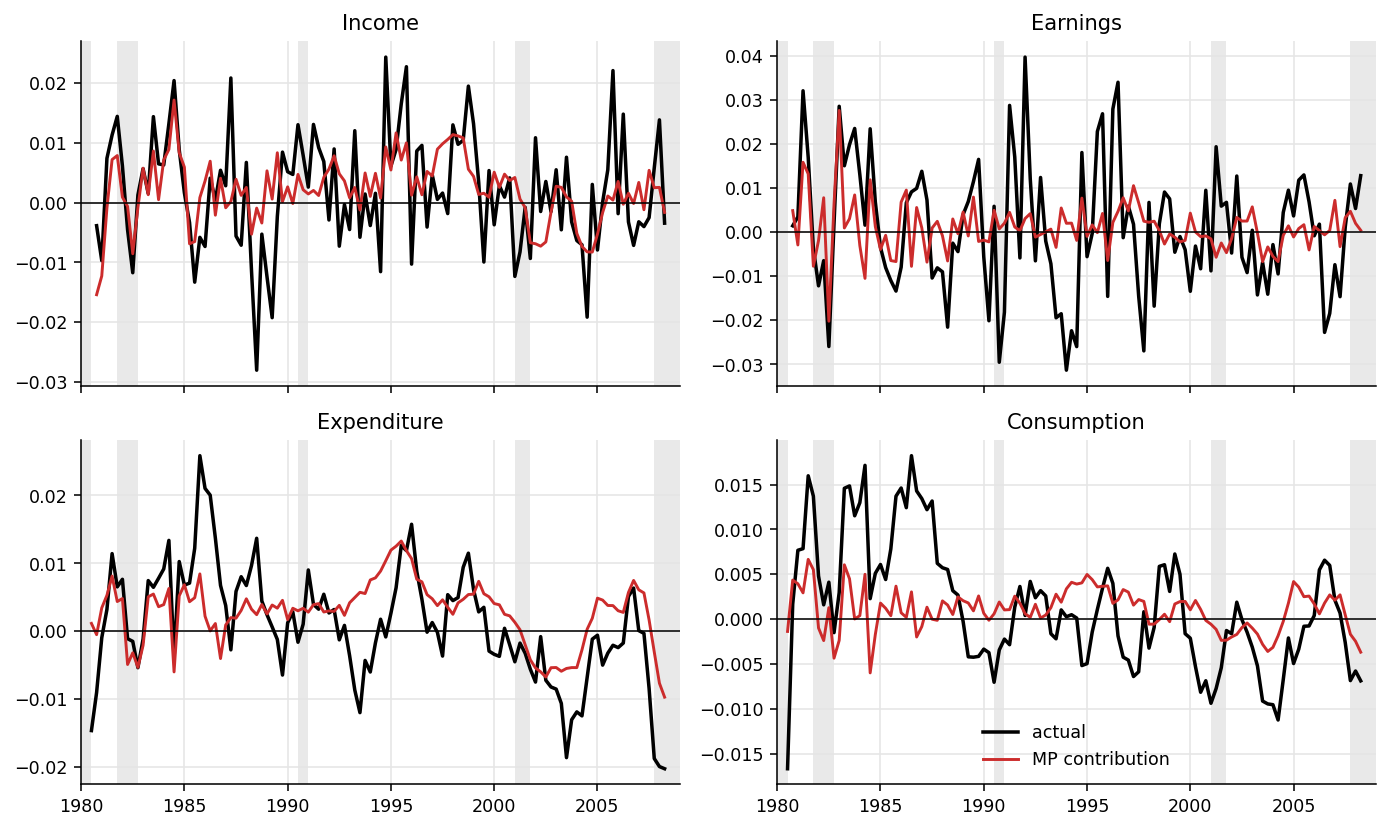

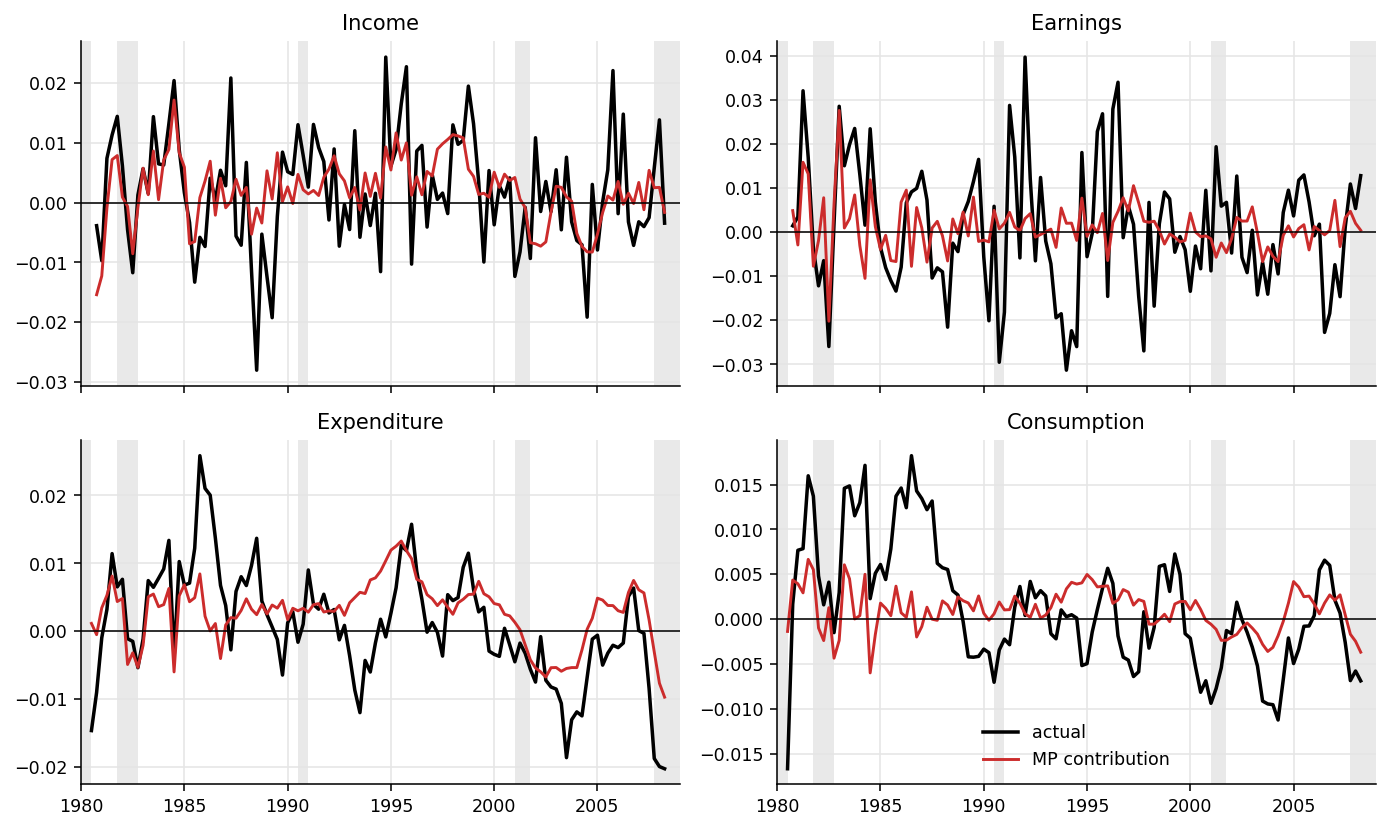

In [5]:
paper_style()
fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True)
for ax, (var, title) in zip(axes.ravel(), hist_vars):
    frame = hist[var]
    shade_recessions(ax)
    ax.plot(frame['time'], frame['actual_ma5_stata'], color='black', lw=1.8, label='actual')
    ax.plot(frame['time'], frame['contribution_ma5_stata'], color='#cc2c2c', lw=1.5, label='MP contribution')
    ax.axhline(0, color='black', lw=0.8)
    ax.set_title(title)
    ax.set_xlim(1980, 2009)
axes[-1, -1].legend(frameon=False)
savefig(fig, paths.figures / 'figure5_historical_contribution.png')
fig

## Deviation Note

Figure 4 follows the original Stata formula, including the known nonstandard FEVD denominator. Figure 5 now plots the Stata-compatible centered five-quarter series, which divides a five-observation sum by 3 as in `step405`; the table also stores corrected moving-average columns for transparency.